# SVM을 사용한 비만도 계산

## SVM : 서포트 벡터 머신
- support vector machine
- 분류형 모델에서 사용
- 주어진 데이터가 어떤 카테고리에 속할지 판단하는 이진 선형(linear)분류 모델

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fbrs4hH%2FbtqwLdV2jMB%2Fak8lLgNQKU2GaR6U9ZEDsk%2Fimg.png)


## Margin 최대화
![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fbh56rr%2FbtqwJd3vppD%2F958jQaBiONdeq2frzmKbV0%2Fimg.png)




In [1]:
# 무작위로 2만명의 키와 몸무게 데이터를 만들고
# 비만도 계산의 BMI 를 사용해 저체중, 정상, 비만 레이블을 붙이기
# 그리고, 이를 SVM 에 학습시키고, 비만도를 정확하게 맞출수 있는지 테스트


# BMI = kg / (m x m)

In [3]:
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random


import time    # 실행시간 측정용도
from time import strftime

# 랜덤 데이터 만들기
2만명 키, 몸무게 데이터 생성

In [5]:
base_path = r'F:\KDT2508\dataset'

In [7]:
# 비만도 계산 함수 
def bmi_calc(h, w): # 키(cm), 몸무게 
    bmi = w / (h/100)**2
    if bmi < 18.5 : return 'thin' # 저체중
    if bmi < 25 : return 'normal' # 정상
    return 'fat' # 과체중

In [9]:
bmi_calc(187, 76)

'normal'

In [10]:
# "키(cm), 몸무게(kg)" -->   "저체중(thin), 정상(normal), 비만(fat)"  출력
# 레이블을 활용해 3개의 컬럼을 갖는 CSV 파일 작성

In [11]:
file_path = os.path.join(base_path, 'bmi.csv')
file_path

'F:\\KDT2508\\dataset\\bmi.csv'

In [14]:
# 20000 개의 데이터 생성 > CSV 저장
cnt = {
    'thin' : 0 ,
    'normal': 0,
    'fat' : 0,
}

with open(file_path, "w", encoding='utf-8') as f:
    f.write('height, weight, label\n')

    random.seed(42)

    for i in range(20000):

        h = random.randint(120,200) # 키 120 ~ 200cm 사이
        w = random.randint(35,80) # 몸무게 35 ~ 80
        label = bmi_calc(h,w)
        cnt[label] += 1
        f.write(f'{h},{w},{label} \n')

print(cnt)

{'thin': 6347, 'normal': 5991, 'fat': 7662}


# 데이터 읽어오기

In [17]:
# CSV = DataFrame
df = pd.read_csv(file_path)

In [18]:
df.head()

,height,weight,label
0,134,36,normal
1,155,50,normal
2,148,43,normal
3,133,78,fat
4,189,40,thin


# 전처리 수행

In [29]:
df.columns = ['height', 'weight', 'label']

In [32]:
df_label = df['label']


In [37]:
df_label.unique()

array(['normal ', 'fat ', 'thin '], dtype=object)

In [40]:
new_label = []

for bmi in df_label:
    if bmi == 'normal ':
        new_label.append(0)
    elif bmi == 'fat ':
        new_label.append(1)
    elif bmi == 'thin ':
        new_label.append(2)

df["label"] = new_label

In [41]:
df.head()

,height,weight,label
0,134,36,0
1,155,50,0
2,148,43,0
3,133,78,1
4,189,40,2


In [42]:
X = df[['height', 'weight']]
y = df['label']

In [19]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

X_scaled

array([[-1.1101744 , -1.61729258],
       [-0.21237283, -0.5652239 ],
       [-0.51164002, -1.09125824],
       ...,
       [ 1.58323033,  0.18625373],
       [ 1.07020085, -0.18948508],
       [ 1.66873524, -0.71551942]], shape=(20000, 2))

In [46]:
X_scaled = pd.DataFrame(X_scaled, index = X.index, columns = X.columns)

In [48]:
X_scaled.head()

,height,weight
0,-1.110174,-1.617293
1,-0.212373,-0.565224
2,-0.511640,-1.091258
3,-1.152927,1.538913
4,1.241211,-1.316702


# train/test 나누기

In [ ]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

In [50]:
X_train.shape, X_test.shape

((14000, 2), (6000, 2))

# 학습진행

In [51]:
from xgboost import XGBClassifier

In [53]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# test 점수 확인

In [55]:
xgb.score(X_test, y_test)

0.9993333333333333

In [63]:
xgb.predict(X_test)

array([1, 2, 2, ..., 0, 2, 1], shape=(6000,))

# 예측하기
임의의 데이터에 대하여

In [138]:
def predict_bmi(h,w):
    X_pred = pd.DataFrame([[h, w]], columns=["height", "weight"])
    X_pred_scaled = scaler.transform(X_pred)
    pred = xgb.predict(X_pred_scaled)[0]
    
    if pred == 0:
        return "normal"
    elif pred == 1:
        return "fat"
    else:
        return "thin"

In [139]:
predict_bmi(178,80)

'fat'

# 평가지표들 확인 

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [144]:
predict = xgb.predict(X_test)
print('accuracy', accuracy_score(y_test, predict))
print('precision', precision_score(y_test, predict, average="macro"))
print('recall', recall_score(y_test, predict, average="macro"))
print('f1-score', f1_score(y_test,predict, average="macro"))

accuracy 0.9993333333333333
precision 0.9993091537132988
recall 0.9992563673545268
f1-score 0.9992819870058761


In [94]:
from sklearn.metrics import classification_report

In [110]:
print(classification_report(
    y_test,
    predict,
    target_names=["normal", "fat", "thin"]
))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      1793
         fat       1.00      1.00      1.00      2281
        thin       1.00      1.00      1.00      1926

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [ ]:
from sklearn.metrics import RocCurveDisplay

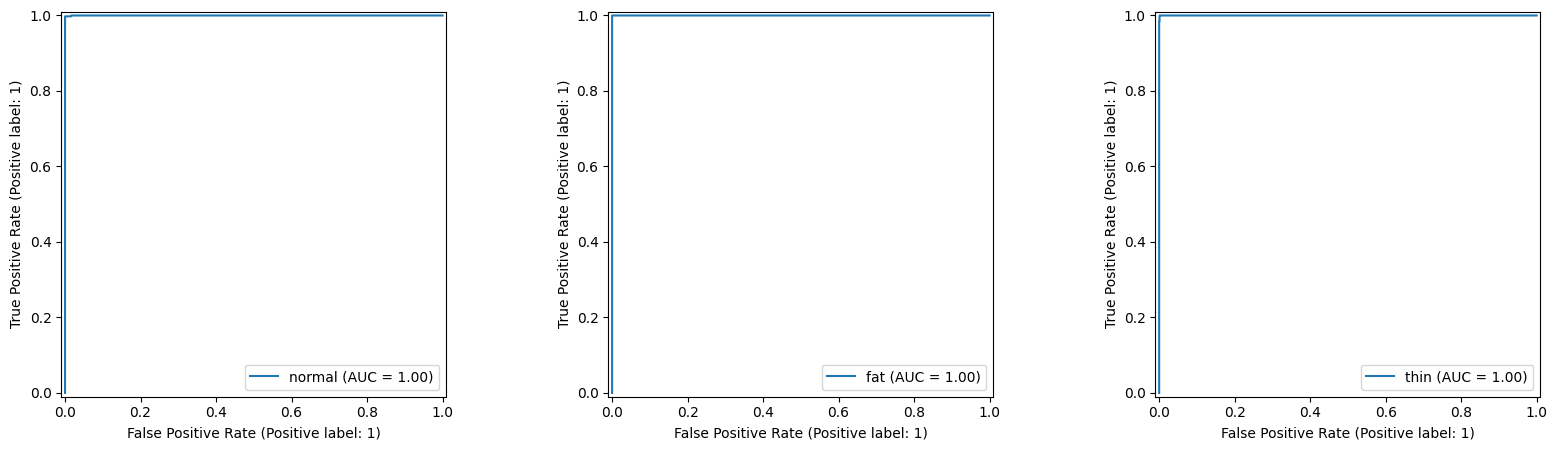

In [145]:
fig,( ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,5))

proba = xgb.predict_proba(X_test)  

RocCurveDisplay.from_predictions(
    y_test == 0,   
    proba[:, 0],              
    name="normal",
    ax=ax1
)

RocCurveDisplay.from_predictions(
    y_test == 1,
    proba[:, 1],
    name="fat",
    ax=ax2
)


RocCurveDisplay.from_predictions(
    y_test == 2,
    proba[:, 2],
    name="thin",
    ax=ax3
)

plt.show()
